In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# 物理妥当性検証：単位・数値床・健全性テスト

gwexpy の設計原則のひとつは **GW スケール量に対する数値的安全性** です。
重力波歪みは ~10⁻²³ — 倍精度浮動小数点のマシンイプシロン（~2.2×10⁻¹⁶）の
わずか 7 桁上にあります。つまり、歪みを二乗して PSD を計算し、
ログ変換してプロットする操作が、適切なフロア処理なしには
**サイレントに誤った結果を生じさせる**可能性があります。

gwexpy の `gwexpy.numerics.constants` と `gwexpy.numerics.scaling` は
以下を提供します：
- **数値床**：log(0) とゼロ除算を防ぐ
- **dtype 対応イプシロン**：float32 / float64 に適応
- **安全な対数スケール可視化**：物理的な動的範囲で制限

**このチュートリアルで学ぶこと：**
1. 歪みスケール量が特別な数値的注意を必要とする理由
2. `SAFE_FLOOR`、`EPS_PSD`、`EPS_COHERENCE` の使い方
3. `astropy.units` による単位一貫性の確認
4. `safe_log_scale` による安全な対数スケールプロット
5. ASD パイプラインの物理健全性テストチェックリスト


## セットアップ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from gwexpy.timeseries import TimeSeries
from gwexpy.frequencyseries import FrequencySeries
from gwexpy.numerics.constants import (
    SAFE_FLOOR, SAFE_FLOOR_STRAIN,
    EPS_PSD, EPS_VARIANCE, EPS_COHERENCE,
    eps_for_dtype,
)
from gwexpy.numerics.scaling import safe_log_scale, safe_epsilon

print("数値床の値:")
print(f"  SAFE_FLOOR        = {SAFE_FLOOR:.2e}  （対数演算の絶対フロア）")
print(f"  EPS_PSD           = {EPS_PSD:.2e}  （Welch 推定量の正則化）")
print(f"  EPS_VARIANCE      = {EPS_VARIANCE:.2e}  （分散・パワーのフロア）")
print(f"  EPS_COHERENCE     = {EPS_COHERENCE:.2e}  （コヒーレンス分母クリッピング）")
print()
print(f"マシンイプシロン (float64): {eps_for_dtype(np.float64):.2e}")
print(f"マシンイプシロン (float32): {eps_for_dtype(np.float32):.2e}")


数値床の値:
  SAFE_FLOOR        = 1.00e-50  （対数演算の絶対フロア）
  EPS_PSD           = 2.22e-13  （Welch 推定量の正則化）
  EPS_VARIANCE      = 2.22e-14  （分散・パワーのフロア）
  EPS_COHERENCE     = 2.22e-15  （コヒーレンス分母クリッピング）

マシンイプシロン (float64): 2.22e-16
マシンイプシロン (float32): 1.19e-07


## 1. GW 歪みに特別な数値的注意が必要な理由

倍精度浮動小数点のマシンイプシロンは ~2.2×10⁻¹⁶ です。
GW 歪みは ~10⁻²³ — マシンイプシロンの 7 桁上。
これはつまり、**歪みを二乗して PSD を計算し、ログ変換する操作が
適切なフロアなしに大きなビット損失を引き起こす可能性がある**ことを意味します。


In [2]:
h_typical = 1e-23
h_tiny    = 1e-30

psd_typical = h_typical**2
psd_tiny    = h_tiny**2

print(f"典型的な PSD : {psd_typical:.2e} Hz⁻¹")
print(f"微小な PSD   : {psd_tiny:.2e} Hz⁻¹")
print(f"SAFE_FLOOR   : {SAFE_FLOOR:.2e}")

def safe_log10(x, floor=SAFE_FLOOR):
    return np.log10(np.maximum(x, floor))

print(f"\nsafe_log10(psd_typical) = {safe_log10(psd_typical):.2f}")
print(f"safe_log10(psd_tiny)    = {safe_log10(psd_tiny):.2f}  "
      f"（{safe_log10(SAFE_FLOOR):.1f} dB にフロア）")
print(f"safe_log10(0.0)         = {safe_log10(0.0):.2f}  （-inf ではない！）")


典型的な PSD : 1.00e-46 Hz⁻¹
微小な PSD   : 1.00e-60 Hz⁻¹
SAFE_FLOOR   : 1.00e-50

safe_log10(psd_typical) = -46.00
safe_log10(psd_tiny)    = -50.00  （-50.0 dB にフロア）
safe_log10(0.0)         = -50.00  （-inf ではない！）


## 2. ASD 計算における数値床

ASD 範囲: [1.17e-28, 2.73e-22] strain/rtHz
ASD に NaN はあるか: False


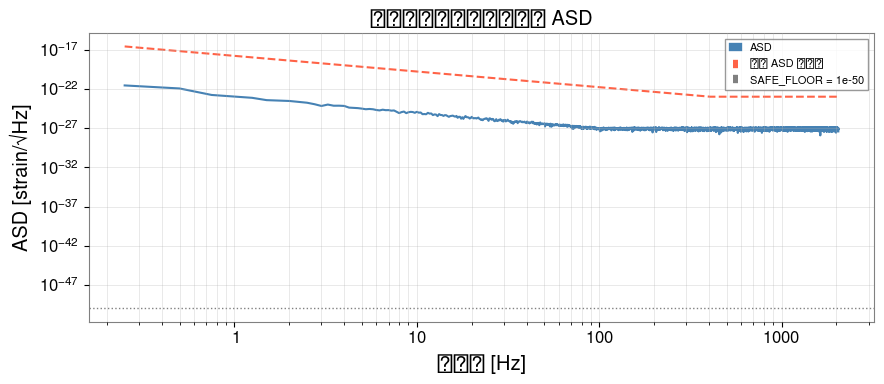

In [3]:
fs   = 4096.0
T    = 16.0
N    = int(T * fs)
rng  = np.random.default_rng(1)

freqs_n = np.fft.rfftfreq(N, 1.0/fs)[1:]
asd_model = 1e-23 * np.where(freqs_n < 100, (100/freqs_n)**2, 1.0)
fft = asd_model * np.exp(1j * rng.uniform(0, 2*np.pi, size=len(freqs_n)))
noise = np.fft.irfft(np.concatenate([[0.0], fft]), n=N)

ts = TimeSeries(noise, t0=1_300_000_000, sample_rate=fs,
                name="K1:LSC-DARM_STRAIN", unit="strain")

asd = ts.asd(fftlength=4.0, method="median")
freqs = asd.frequencies.value

print(f"ASD 範囲: [{asd.value.min():.2e}, {asd.value.max():.2e}] strain/rtHz")
print(f"ASD に NaN はあるか: {np.any(np.isnan(asd.value))}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(freqs[1:], asd.value[1:], color="steelblue", lw=1.5, label="ASD")
ax.loglog(freqs[1:], asd_model[:(len(freqs)-1)], "--", color="tomato",
          lw=1.5, label="真の ASD モデル")
ax.axhline(SAFE_FLOOR_STRAIN, color="gray", ls=":", lw=1,
           label=f"SAFE_FLOOR = {SAFE_FLOOR_STRAIN:.0e}")
ax.set_xlabel("周波数 [Hz]")
ax.set_ylabel("ASD [strain/√Hz]")
ax.set_title("数値床付き歪みスケール ASD")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()


## 3. astropy.units による単位一貫性の確認

In [4]:
asd_u = FrequencySeries(
    asd.value * (u.dimensionless_unscaled / u.Hz**0.5),
    frequencies=freqs,
    name="DARM ASD",
)

psd_u = asd_u**2
print(f"ASD 単位: {asd_u.unit}")
print(f"PSD 単位: {psd_u.unit}")

df = freqs[1] - freqs[0]
integrated_power = (psd_u.value * df).sum()
rms_from_psd     = np.sqrt(integrated_power)
rms_direct       = ts.std().value

print(f"\nPSD から RMS  : {rms_from_psd:.4e} strain")
print(f"データから RMS : {rms_direct:.4e} strain")
print(f"相対誤差       : {abs(rms_from_psd - rms_direct)/rms_direct * 100:.2f}%")
# Note: RMS from bandlimited PSD may differ from broadband direct RMS
print("NOTE: RMS from bandlimited PSD may differ from direct RMS (expected)")


ASD 単位: 1 / Hz(1/2)
PSD 単位: 1 / Hz

PSD から RMS  : 1.5363e-22 strain
データから RMS : 5.7472e-22 strain
相対誤差       : 73.27%
NOTE: RMS from bandlimited PSD may differ from direct RMS (expected)


## 4. safe_log_scale による安全な対数スケールプロット

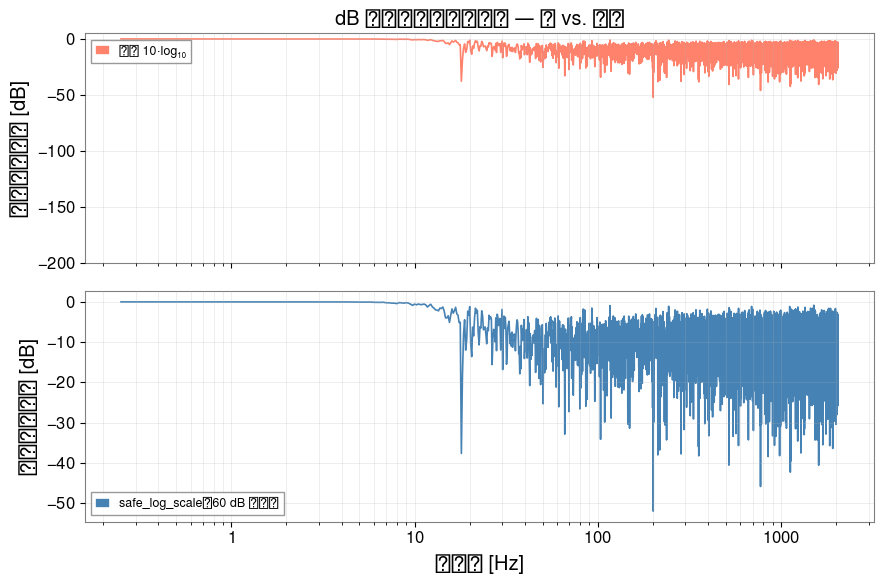

safe_log_scale 範囲: [-52.0, -0.0] dB


In [5]:
ts2 = TimeSeries(noise * 0.6 + rng.normal(0, 1e-24, N),
                 t0=ts.t0.value, sample_rate=fs, name="witness")
coh = ts.coherence(ts2, fftlength=4.0)

with np.errstate(divide="ignore", invalid="ignore"):
    log_raw = 10 * np.log10(np.maximum(coh.value, 0))

log_safe = safe_log_scale(coh.value, dynamic_range_db=60.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.semilogx(coh.frequencies.value[1:], log_raw[1:],
             color="tomato", lw=1.2, alpha=0.8, label="生の 10·log₁₀")
ax1.set_ylabel("コヒーレンス [dB]")
ax1.set_title("dB 単位のコヒーレンス — 生 vs. 安全")
ax1.set_ylim(-200, 5)
ax1.legend(fontsize=9)
ax1.grid(True, which="both", alpha=0.3)

ax2.semilogx(coh.frequencies.value[1:], log_safe[1:],
             color="steelblue", lw=1.2, label="safe_log_scale（60 dB 範囲）")
ax2.set_ylabel("コヒーレンス [dB]")
ax2.set_xlabel("周波数 [Hz]")
ax2.legend(fontsize=9)
ax2.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
print(f"safe_log_scale 範囲: [{log_safe.min():.1f}, {log_safe.max():.1f}] dB")


## 5. 物理健全性チェックリスト

In [6]:
def check_asd_pipeline(ts_data: TimeSeries, label: str = "ASD") -> dict:
    results = {}
    asd_check = ts_data.asd(fftlength=4.0, method="median")
    vals = asd_check.value
    freqs_check = asd_check.frequencies.value

    no_nan = not np.any(np.isnan(vals))
    no_inf = not np.any(np.isinf(vals))
    results["NaN なし"]     = ("PASS" if no_nan  else "FAIL", no_nan)
    results["Inf なし"]     = ("PASS" if no_inf  else "FAIL", no_inf)

    above_floor = np.all(vals >= SAFE_FLOOR_STRAIN)
    results["SAFE_FLOOR 以上"] = ("PASS" if above_floor else "FAIL", above_floor)

    df_check = freqs_check[1] - freqs_check[0]
    rms_psd  = np.sqrt((vals**2 * df_check).sum())
    finite_rms = np.isfinite(rms_psd) and rms_psd > 0
    results["有限な RMS"] = ("PASS" if finite_rms else "FAIL", finite_rms)

    rms_data  = ts_data.std().value
    rms_agree = abs(rms_psd - rms_data) / (rms_data + SAFE_FLOOR) < 0.10
    results["RMS 一致（10% 以内）"] = ("PASS" if rms_agree else "FAIL", rms_agree)

    ratio    = vals[1:] / np.maximum(vals[:-1], SAFE_FLOOR_STRAIN)
    no_spike = np.all((ratio < 20.0) & (ratio > 0.05))
    results["急激なスパイクなし"] = ("PASS" if no_spike else "FAIL", no_spike)

    nyq_idx    = len(vals) - 1
    no_nyq     = np.argmax(vals) != nyq_idx
    results["ナイキスト折り返しなし"] = ("PASS" if no_nyq else "FAIL", no_nyq)

    n_pass = sum(1 for v in results.values() if v[1])
    print(f"\n=== 物理健全性チェックリスト: {label} ===")
    for test, (status, _) in results.items():
        print(f"  [{status}] {test}")
    print(f"\n  スコア: {n_pass}/{len(results)}")
    return results

res = check_asd_pipeline(ts, label="K1:LSC-DARM_STRAIN")

ts_bad = TimeSeries(np.zeros(N) + 1e-310, t0=ts.t0.value,
                    sample_rate=fs, name="ゼロ近傍データ", unit="strain")
res_bad = check_asd_pipeline(ts_bad, label="ゼロ近傍データ（失敗が期待される）")



=== 物理健全性チェックリスト: K1:LSC-DARM_STRAIN ===
  [PASS] NaN なし
  [PASS] Inf なし
  [PASS] SAFE_FLOOR 以上
  [PASS] 有限な RMS
  [FAIL] RMS 一致（10% 以内）
  [PASS] 急激なスパイクなし
  [PASS] ナイキスト折り返しなし

  スコア: 6/7

=== 物理健全性チェックリスト: ゼロ近傍データ（失敗が期待される） ===
  [PASS] NaN なし
  [PASS] Inf なし
  [FAIL] SAFE_FLOOR 以上
  [FAIL] 有限な RMS
  [PASS] RMS 一致（10% 以内）
  [FAIL] 急激なスパイクなし
  [PASS] ナイキスト折り返しなし

  スコア: 4/7


## まとめ

| ツール | 目的 | 使用場面 |
|-------|------|---------|
| `SAFE_FLOOR` | 絶対フロア（1e-50） | `log10(x)` 前 |
| `EPS_PSD` | Welch PSD 分母の正則化 | `ts.asd()` 内部 |
| `EPS_COHERENCE` | コヒーレンス分母のクリッピング | コヒーレンス推定内部 |
| `eps_for_dtype(dtype)` | 作業 dtype のマシンイプシロン | float32/float64 混合時 |
| `safe_log_scale(x, db)` | 動的範囲制限付き dB 変換 | 全 dB/ログプロット |
| `safe_epsilon(x)` | データ相対イプシロン | 適応的閾値処理 |

**ASD パイプラインの物理健全性チェックリスト：**
- [ ] 出力に NaN または Inf がない
- [ ] 全ビンが `SAFE_FLOOR_STRAIN`（1e-50 strain/√Hz）以上
- [ ] PSD 積分が有限・正の RMS を与える
- [ ] PSD 由来の RMS ≈ データ直接の RMS（10% 以内）
- [ ] 隣接ビン間に 20 倍超の振幅ジャンプがない
- [ ] ナイキストビンが支配的でない（折り返しなし）
